# Módulo 1 — Dia 2
## Bibliotecas Científicas & Boas Práticas de Código

Exercícios práticos com NumPy, Pandas, Matplotlib/Plotly e SciPy, além de um checklist de boas
práticas (documentação e reprodutibilidade). A prática de Git/GitHub é feita fora do notebook,
diretamente no terminal — veja as instruções na última seção.

## 1. NumPy — Arrays e Vetorização

### Exercício 2.1
Complete as células abaixo para comparar o desempenho de um laço `for` puro em Python com a
versão vetorizada em NumPy, calculando o quadrado de cada elemento de um vetor grande.

In [1]:
import numpy as np

n = 1_000_000
valores = list(range(n))
v = np.arange(n)


In [2]:
%%timeit
# versão com laço puro em Python
quadrados = [x ** 2 for x in valores]


56.6 ms ± 2.85 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [3]:
%%timeit
# versão vetorizada com NumPy
quadrados_np = v ** 2


1.01 ms ± 43.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Compare os tempos exibidos acima. Qual foi, aproximadamente, o fator de aceleração da versão
vetorizada?

### Exercício 2.2 — Álgebra linear básica

Resolva o sistema linear abaixo usando `np.linalg.solve`:

$$\begin{cases} 2x + y = 8 \\ x - y = 1 \end{cases}$$

In [4]:
A = np.array([[2, 1],
              [1, -1]])
b = np.array([8, 1])

# TODO: resolva o sistema Ax = b
x = np.linalg.solve(A, b)
print("Solução:", x)

# Verificação
print("A @ x =", A @ x, " (deve ser igual a b =", b, ")")


Solução: [3. 2.]
A @ x = [8. 1.]  (deve ser igual a b = [8 1] )


## 2. Pandas — Dados Tabulares

### Exercício 2.3
Usando os dados de posição da bola em queda livre (Dia 1), monte um DataFrame e explore-o.

In [5]:
import pandas as pd

dados = pd.DataFrame({
    "tempo_s": [0, 0.2, 0.4, 0.6, 0.8, 1.0],
    "altura_m": [5.0, 4.80, 4.22, 3.24, 1.86, 0.10],
})

print(dados)
print()
print(dados.describe())


   tempo_s  altura_m
0      0.0      5.00
1      0.2      4.80
2      0.4      4.22
3      0.6      3.24
4      0.8      1.86
5      1.0      0.10

        tempo_s  altura_m
count  6.000000  6.000000
mean   0.500000  3.203333
std    0.374166  1.910368
min    0.000000  0.100000
25%    0.250000  2.205000
50%    0.500000  3.730000
75%    0.750000  4.655000
max    1.000000  5.000000


In [6]:
# TODO: filtre apenas as linhas em que a altura ainda é positiva (altura_m > 0)
dados_positivos = dados[dados["altura_m"] > 0]
dados_positivos


,tempo_s,altura_m
0,0.0,5.00
1,0.2,4.80
2,0.4,4.22
3,0.6,3.24
4,0.8,1.86
5,1.0,0.10


## 3. Matplotlib & Plotly — Visualização

### Exercício 2.4
Plote a altura em função do tempo, primeiro com Matplotlib e depois com Plotly.

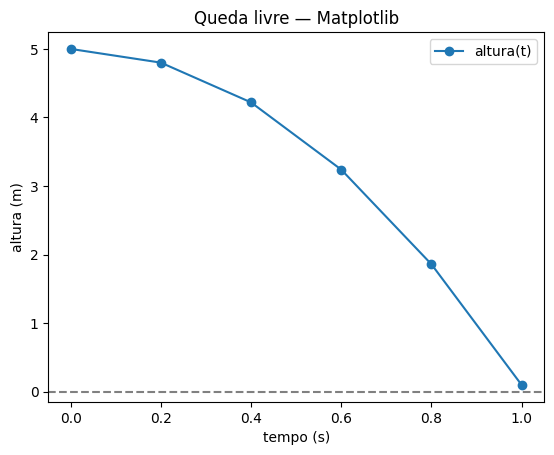

In [7]:
import matplotlib.pyplot as plt

plt.plot(dados["tempo_s"], dados["altura_m"], marker="o", label="altura(t)")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("tempo (s)")
plt.ylabel("altura (m)")
plt.title("Queda livre — Matplotlib")
plt.legend()
plt.show()


In [8]:
import plotly.express as px

fig = px.line(dados, x="tempo_s", y="altura_m", markers=True,
               labels={"tempo_s": "tempo (s)", "altura_m": "altura (m)"},
               title="Queda livre — Plotly (interativo)")
fig.show()


## 4. SciPy — Visão Geral

### Exercício 2.5
Use `scipy.optimize.brentq` para encontrar em que instante a bola atinge o chão (altura = 0),
a partir dos dados acima, ajustando uma função contínua `h(t) = 5 - 0.5*9.81*t**2`.

In [9]:
from scipy.optimize import brentq

def altura(t, h0=5.0, g=9.81):
    return h0 - 0.5 * g * t**2

# TODO: encontre a raiz de altura(t) no intervalo [0, 2]
t_impacto = brentq(altura, 0, 2)
print(f"A bola atinge o chão em t = {t_impacto:.3f} s")


A bola atinge o chão em t = 1.010 s


## 5. Boas práticas — Documentação e reprodutibilidade

### Checklist rápido
Antes de encerrar, revise seu notebook com o checklist abaixo (marque mentalmente ou em texto):

- [ ] As funções que você escreveu têm docstring explicando parâmetros e retorno?
- [ ] Você fixou uma semente aleatória (`np.random.seed(42)`) em qualquer célula que use
      aleatoriedade?
- [ ] Este notebook roda do início ao fim sem erros, na ordem (`Kernel → Restart & Run All`)?
- [ ] Você tem um `requirements.txt` (ou sabe quais bibliotecas usou) para reproduzir o ambiente?

### Exemplo de função documentada

In [10]:
def energia_potencial(massa, altura, g=9.81):
    """
    Calcula a energia potencial gravitacional.

    Parâmetros
    ----------
    massa : float
        Massa do objeto em kg.
    altura : float
        Altura em metros.
    g : float, opcional
        Aceleração da gravidade em m/s^2 (padrão: 9.81).

    Retorna
    -------
    float
        Energia potencial em joules.
    """
    return massa * g * altura


print(energia_potencial(2.0, 5.0), "J")


98.10000000000001 J


## 6. Git & GitHub — prática fora do notebook

Esta parte é feita no terminal, não no Jupyter. Siga os passos abaixo (substitua pelos seus
dados):

```bash
git config --global user.name "Seu Nome"
git config --global user.email "seu@email.com"

git init
git add .
git commit -m "Dia 2: bibliotecas científicas e boas práticas"

git remote add origin https://github.com/SEU-USUARIO/modelagem-computacional.git
git branch -M main
git push -u origin main
```

Depois, no site do GitHub, adicione sua dupla como colaboradora em
**Settings → Collaborators**.